<a href="https://colab.research.google.com/github/miguelmorandini/am-t4-s1a2026/blob/main/aula0414_amt4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline | Carregamento e Detecção de Anomalias [Fase 1 - credit_data]

## Importar dados do Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Bibliotecas de Python

In [ ]:
!pip -q install plotly        #instala biblioteca para gráficos interativos (zoom, hover, dashboards)
!pip -q install yellowbrick   #instala visualizações para modelos de ML (curvas, clusters, métricas)

In [ ]:
import pandas as pd               #manipulação de dados (tabelas/DataFrame)
import numpy as np                #operações matemáticas e arrays
import seaborn as sns             #gráficos estatísticos mais simples
import matplotlib.pyplot as plt   #criação de gráficos básicos
import plotly.express as px       #gráficos interativos

## Importar DataFrame [base_credit] - Descrição da Base

In [ ]:
base_credit = pd.read_csv('/content/drive/MyDrive/DSM/5º Semestre - 2026/aprendizagem-de-maquina/amt4/credit_data.csv')

In [ ]:
base_credit

,clientid,income,age,loan,default
0,1,66155.925095,59.017015,8106.532131,0
1,2,34415.153966,48.117153,6564.745018,0
2,3,57317.170063,63.108049,8020.953296,0
3,4,42709.534201,45.751972,6103.642260,0
4,5,66952.688845,18.584336,8770.099235,1
...,...,...,...,...,...
1995,1996,59221.044874,48.518179,1926.729397,0
1996,1997,69516.127573,23.162104,3503.176156,0
1997,1998,44311.449262,28.017167,5522.786693,1
1998,1999,43756.056605,63.971796,1622.722598,0


In [ ]:
base_credit.describe()

,clientid,income,age,loan,default
count,2000.000000,2000.000000,1997.000000,2000.000000,2000.000000
mean,1000.500000,45331.600018,40.807559,4444.369695,0.141500
std,577.494589,14326.327119,13.624469,3045.410024,0.348624
min,1.000000,20014.489470,-52.423280,1.377630,0.000000
25%,500.750000,32796.459717,28.990415,1939.708847,0.000000
50%,1000.500000,45789.117313,41.317159,3974.719419,0.000000
75%,1500.250000,57791.281668,52.587040,6432.410625,0.000000
max,2000.000000,69995.685578,63.971796,13766.051239,1.000000


## Analise Exploratória de Anomalias [Alunos]

Possíveis idades negativas - (Incongruencias ou Impossibilidade) | resultante: Normalização

In [ ]:
base_credit.loc[base_credit['age'] < 0]

,clientid,income,age,loan,default
15,16,50501.726689,-28.218361,3977.287432,0
21,22,32197.620701,-52.423280,4244.057136,0
26,27,63287.038908,-36.496976,9595.286289,0


Possíveis ganhos (renda) negativos - (Incongruencias ou Impossibilidade) | resultante: Nulos

In [ ]:
base_credit.loc[base_credit['income'] < 0]

,clientid,income,age,loan,default


Possíveis Nulidades - (Dados nulos em base) | resultante: Normalização

In [ ]:
base_credit.isnull().sum()

,0
clientid,0
income,0
age,3
loan,0
default,0


In [ ]:
base_credit[base_credit.isnull().any(axis=1)]

,clientid,income,age,loan,default
28,29,59417.805406,NaN,2082.625938,0
30,31,48528.852796,NaN,6155.784670,0
31,32,23526.302555,NaN,2862.010139,0


Possibilidade de Dividade Negativa (Incongruencia ou Impossibilidade) | resultante: Nulo

In [ ]:
base_credit.loc[base_credit['loan'] < 0]

,clientid,income,age,loan,default


# Pipeline | Visualização de Dados e Anomalias [Fase 2 base_credit]

## Eixo de Alvos de Apredizagem

In [ ]:
np.unique(base_credit['default'], return_counts=True)

(array([0, 1]), array([1717,  283]))

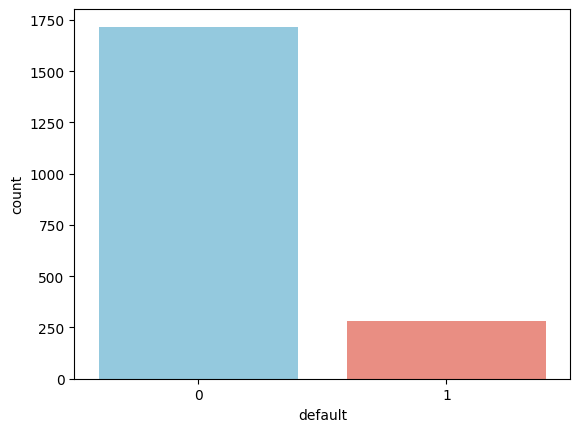

In [ ]:
sns.countplot(
    x=base_credit['default'],
    hue=base_credit['default'],
    palette=['skyblue', 'salmon'],
    legend=False
);

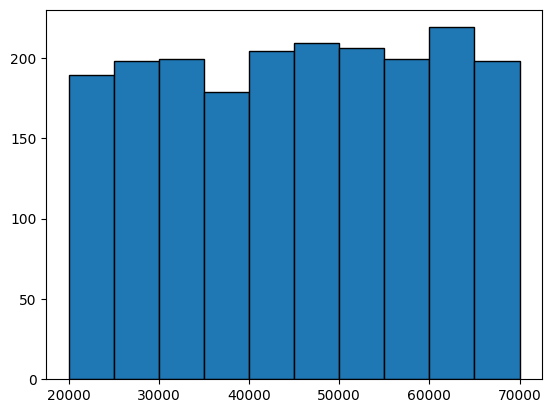

In [ ]:
plt.hist(x=base_credit['income'], edgecolor="black");

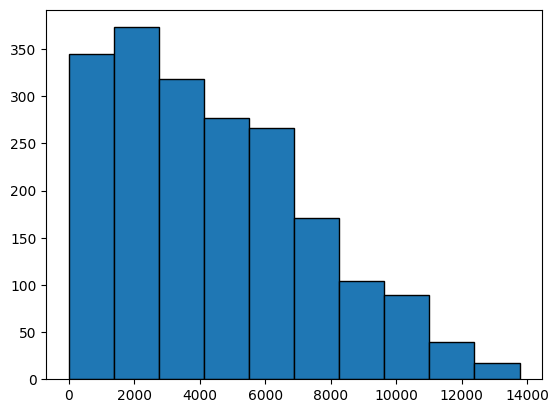

In [ ]:
plt.hist(x=base_credit['loan'], edgecolor="black");

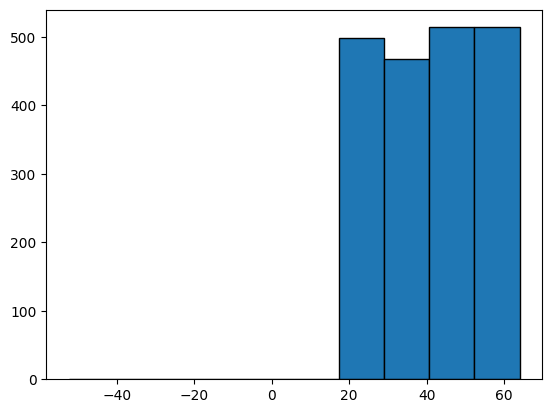

In [ ]:
plt.hist(x=base_credit['age'], edgecolor="black");

Gráfico detecta a área negativa de anomalias | confirmada em analise.

In [ ]:
grafico_credito = px.scatter_matrix(base_credit, dimensions=['age', 'income', 'loan'], color='default')
grafico_credito.show()

Error: could not locate runnable browser